In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error,r2_score
import pandas as pnd


<h1 style="color: red;">Section 1: Data</h1>

<h2>1) Préparation de données</h2>

In [2]:
np.random.seed(44) #à chaque exécution,générer le même dataset de manière aléatoire
# Coefficients
a1, a2, b = 2, 3, 5  # y = 2*X1 + 3*X2 + 5 + bruit
nombre_points = 100 # Nombre de points
# Génération des deux features (X1 et X2)
X1 = np.random.rand(nombre_points) * 10
X2 = np.random.rand(nombre_points) * 10
# Empilement des features dans une seule matrice (shape: (100, 2))
X = np.column_stack((X1, X2))
# Génération du bruit
bruit = np.random.randn(nombre_points) * 2  # Bruit
# Calcul de la target
y = a1 * X1 + a2 * X2 + b + bruit

#spilt data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)


<h1 style="color: red;">Section 2: Neural network avec tensorflow</h1>

In [3]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

I0000 00:00:1778428139.028023   29481 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778428139.028637   29481 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778428139.075774   29481 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778428140.642582   29481 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

<h2>2) Modèle de réseau de neurones</h2>

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Définition du modèle
model_nn = Sequential()
# On ajoute une couche Dense (totalement connectée) avec 1 seul neurone. 
# input_shape=(2,) car nous avons 2 features (X1 et X2).
model_nn.add(Dense(units=1, input_shape=(2,))) 

# 2. Compilation du modèle
# Pour une régression, la fonction de perte (loss) standard est l'Erreur Quadratique Moyenne (MSE).
# L'optimiseur 'sgd' (Stochastic Gradient Descent) ou 'adam' est classique ici.
model_nn.compile(optimizer='sgd', loss='mse') 

# 3. Entraînement du modèle
# On entraîne le modèle sur l'ensemble d'entraînement. epochs définit le nombre de passages.
history = model_nn.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100


/workspaces/ML_basics/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778428141.023996   29481 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 189.8297 - val_loss: 7.3197
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 9.0794 - val_loss: 6.4877
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 8.1374 - val_loss: 6.1243
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 7.4924 - val_loss: 6.2627
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 6.9699 - val_loss: 7.5361
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 7.7599 - val_loss: 7.5760
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 6.6640 - val_loss: 6.5726
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 6.8551 - val_loss: 6.5583
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 6.6299 - val_loss: 7.5302
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 7.2350 - val_loss: 7.6260
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 6.6052 - val_loss: 6.8725
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 6.4343 - val_loss: 6.72

In [5]:
poids, biais = model_nn.layers[0].get_weights()
print(f"Poids (w1, w2) : {poids.flatten()}")
print(f"Biais (b) : {biais}")

Poids (w1, w2) : [2.1945577 3.361812 ]
Biais (b) : [2.0869305]


<h2>3) Prédiction en utilisant le modèle</h2>

In [6]:
yhat_nn=model_nn.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [7]:
yhat_nn = model_nn.predict(X_test)

# Affichage des 5 premières prédictions pour vérifier
print("Prédictions avec Keras :")
print(yhat_nn[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prédictions avec Keras :
[[41.732407]
 [44.066086]
 [38.231323]
 [27.628654]
 [42.41545 ]]


In [8]:
yhat_nn=yhat_nn.flatten()

In [9]:
W_nn, bias_nn = model_nn.layers[0].get_weights()

# Afficher les poids et biais
print("Poids :", W_nn.flatten())
print("Biais :", bias_nn)

Poids : [2.1945577 3.361812 ]
Biais : [2.0869305]


In [10]:
# On récupère les poids (W) et le biais (b) appris par le réseau
W, b = model_nn.layers[0].get_weights()

# On fait le calcul mathématique : X_test multiplié par W, plus le biais
yhat_manuel = X_test @ W + b

# On affiche les 5 premiers résultats pour comparer avec yhat_nn
print("Résultats du calcul manuel :")
print(yhat_manuel[:5])

# Optionnel : Vérification automatique
print(f"Les deux méthodes sont identiques: {np.allclose(yhat_nn, yhat_manuel, atol=1e-4)}")

Résultats du calcul manuel :
[[41.7324118 ]
 [44.06609043]
 [38.23132368]
 [27.62865438]
 [42.41545094]]
Les deux méthodes sont identiques: False


<h2>4) Evaluation du modèle</h2>

5.120026062021095 0.9622948875501791


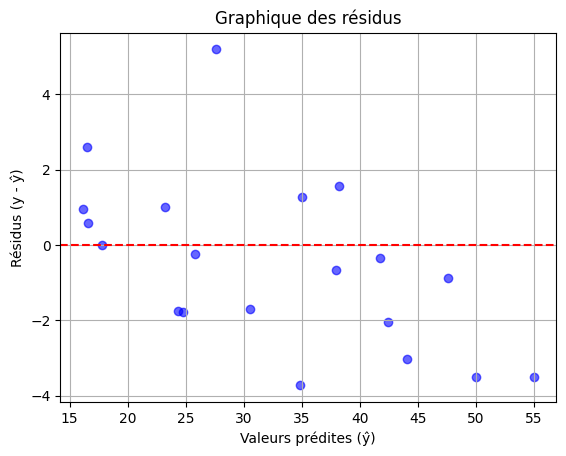

In [11]:
mse_nn,r2_nn=mean_squared_error(yhat_nn,y_test),r2_score(yhat_nn,y_test)
print(mse_nn,r2_nn)

import matplotlib.pyplot as plt

# Tracé des résidus
plt.scatter(yhat_nn, y_test - yhat_nn, color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites (ŷ)")
plt.ylabel("Résidus (y - ŷ)")
plt.title("Graphique des résidus")
plt.grid(True)
plt.show()


In [12]:
# --- 4-a) Performance du modèle sur le training set ---
# Il faut d'abord faire les prédictions sur les données d'entraînement
yhat_train = model_nn.predict(X_train)

# Calcul des métriques (MSE et R2)
mse_train = mean_squared_error(y_train, yhat_train)
r2_train = r2_score(y_train, yhat_train)

print("--- Performances sur le Training Set ---")
print(f"MSE : {mse_train:.4f}")
print(f"R2  : {r2_train:.4f}")

# --- 4-b) Performance du modèle sur le test set ---
# On utilise yhat_nn que vous avez déjà calculé dans la Section 3
mse_test = mean_squared_error(y_test, yhat_nn)
r2_test = r2_score(y_test, yhat_nn)

print("\n--- Performances sur le Test Set ---")
print(f"MSE : {mse_test:.4f}")
print(f"R2  : {r2_test:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
--- Performances sur le Training Set ---
MSE : 5.1132
R2  : 0.9379

--- Performances sur le Test Set ---
MSE : 5.1200
R2  : 0.9545


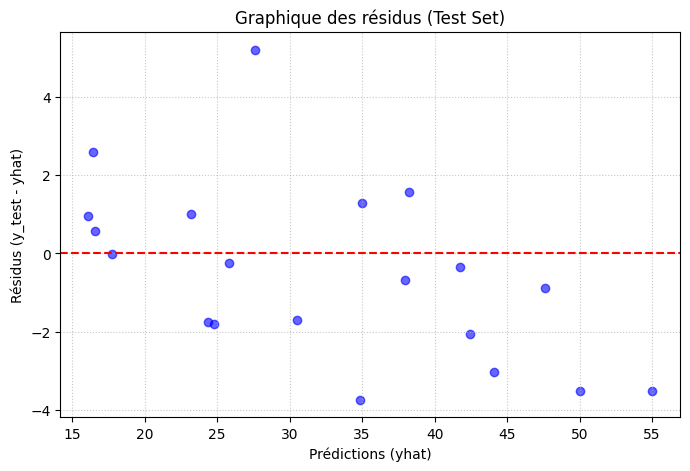

In [ ]:
# Calcul des résidus sur l'ensemble de test
residus = y_test - yhat_nn

# Tracé du graphique avec matplotlib
plt.figure(figsize=(8, 5))
plt.scatter(yhat_nn, residus, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--') # Ajoute une ligne horizontale à 0
plt.title("Graphique des résidus (Test Set)")
plt.xlabel("Prédictions (yhat)")
plt.ylabel("Résidus (y_test - yhat)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

<h1>From scratch</h1>


<h1 style="color: red;"> Section 3 :Régression linéaire from scratch </h1>


<h2>Modèle (version1) de régression linéaire from scratch avec utilisation des matrices</h2>


In [14]:
learning_rate = 0.0001
epochs = 1000


# Initialisation des paramètres
W = np.array([[0.0], [0.0]])  # Shape: (2, 1)
b = 0.0

# Reshape y_train pour garantir les dimensions adéquates 
y_train = y_train.reshape(-1, 1)  # Shape: (n_samples, 1)
n = len(X_train)

# Entraînement (descente de gradient vectorisée)
for epoch in range(epochs):
    y_pred = X_train @ ?#compéter, @ pour un produit entre matrices  # Shape: (n, 1)
    error = y_pred - y_train  # Shape: (n, 1)

    # Calcul des gradients
    dW = (1/n) * (?) #compéter  # Shape: (2, 1)
    db = (1/n) * np.sum(error)        # Scalaire

    # Mise à jour des paramètres
    W -= ?#compéter
    b -= learning_rate * db

# Résultats
print("Paramètres ajustés:")
print(f"W = \n{W}")
print(f"b = {b:.4f}")

SyntaxError: invalid syntax (2533215839.py, line 15)